# Assignment 2: Data Engineering with PySpark
> Students : DIALLO Samba & DIOP Mouhamed
---

## Overview
This assignment focuses on building a data engineering pipeline using PySpark to process and analyze e-commerce operational data from SQLite.

## Objectives
- Set up PySpark environment
- Load and explore data from SQLite database
- Perform data transformations
- Analyze sales and customer behavior patterns
- Export processed data

## Part 1: Environment Setup

In [1]:
# Install required packages
!pip install pyspark pandas numpy matplotlib seaborn

In [2]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Assignment2_DataEngineering") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark session created successfully")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/05 02:01:56 WARN Utils: Your hostname, sable-ThinkPad-X1-Yoga-3rd, resolves to a loopback address: 127.0.1.1; using 10.192.33.105 instead (on interface wlp2s0)
26/01/05 02:01:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/05 02:01:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created successfully
Spark version: 4.0.1


## Part 2: Data Loading and Exploration

In [4]:
# Create SQLite database from SQL dump
import sqlite3
import os

# Path to SQL file
sql_file = "/home/sable/Badr TAJINI/lab2-practice/lab2_operational_dump.sql"
db_file = "/home/sable/Badr TAJINI/lab2-practice/operational.db"

# Remove old database if exists
if os.path.exists(db_file):
    os.remove(db_file)

# Create database and load data
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# Read and execute SQL file
with open(sql_file, 'r') as f:
    sql_script = f.read()
    cursor.executescript(sql_script)

conn.commit()
conn.close()

print("Database created and data loaded successfully")

Database created and data loaded successfully


In [6]:
# Load data from SQLite database using pandas then convert to Spark
print("Loading data from database...")

# Connect to SQLite
db_path = "/home/sable/Badr TAJINI/lab2-practice/operational.db"
conn_read = sqlite3.connect(db_path)

# Load tables into pandas DataFrames first
customers_pd = pd.read_sql_query("SELECT * FROM customers", conn_read)
orders_pd = pd.read_sql_query("SELECT * FROM orders", conn_read)
order_items_pd = pd.read_sql_query("SELECT * FROM order_items", conn_read)
products_pd = pd.read_sql_query("SELECT * FROM products", conn_read)
brands_pd = pd.read_sql_query("SELECT * FROM brands", conn_read)
categories_pd = pd.read_sql_query("SELECT * FROM categories", conn_read)

conn_read.close()

# Convert pandas DataFrames to Spark DataFrames
customers_df = spark.createDataFrame(customers_pd)
orders_df = spark.createDataFrame(orders_pd)
order_items_df = spark.createDataFrame(order_items_pd)
products_df = spark.createDataFrame(products_pd)
brands_df = spark.createDataFrame(brands_pd)
categories_df = spark.createDataFrame(categories_pd)

print("Data loaded successfully")
print(f"Customers: {customers_df.count()}")
print(f"Orders: {orders_df.count()}")
print(f"Order items: {order_items_df.count()}")

Loading data from database...
Data loaded successfully


Customers: 24
Orders: 220
Order items: 638


In [7]:
# Display sample data from each table
print("Sample customers:")
customers_df.show(5)

print("\nSample orders:")
orders_df.show(5)

print("\nSample products:")
products_df.show(5)

Sample customers:
+-----------+----------+----------------+-------------------+
|customer_id|      name|           email|         created_at|
+-----------+----------+----------------+-------------------+
|          1|Customer 1|c001@example.com|2025-01-02T10:00:00|
|          2|Customer 2|c002@example.com|2025-01-03T10:00:00|
|          3|Customer 3|c003@example.com|2025-01-04T10:00:00|
|          4|Customer 4|c004@example.com|2025-01-05T10:00:00|
|          5|Customer 5|c005@example.com|2025-01-06T10:00:00|
+-----------+----------+----------------+-------------------+
only showing top 5 rows

Sample orders:
+--------+-----------+-------------------+
|order_id|customer_id|         order_date|
+--------+-----------+-------------------+
|       1|          5|2025-03-07T12:22:00|
|       2|         14|2025-02-16T17:00:00|
|       3|         21|2025-04-11T12:28:00|
|       4|          6|2025-06-15T17:13:00|
|       5|         17|2025-05-22T16:29:00|
+--------+-----------+------------------

In [8]:
# Display schemas
print("Customers schema:")
customers_df.printSchema()

print("\nOrders schema:")
orders_df.printSchema()

print("\nProducts schema:")
products_df.printSchema()

Customers schema:
root
 |-- customer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- created_at: string (nullable = true)


Orders schema:
root
 |-- order_id: long (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- order_date: string (nullable = true)


Products schema:
root
 |-- product_id: long (nullable = true)
 |-- product_name: string (nullable = true)
 |-- brand_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- price: double (nullable = true)



In [9]:
# Basic statistics
print("Customers statistics:")
customers_df.describe().show()

print("\nOrders statistics:")
orders_df.describe().show()

Customers statistics:


26/01/05 02:04:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+----------+----------------+-------------------+
|summary|       customer_id|      name|           email|         created_at|
+-------+------------------+----------+----------------+-------------------+
|  count|                24|        24|              24|                 24|
|   mean|              12.5|      NULL|            NULL|               NULL|
| stddev|7.0710678118654755|      NULL|            NULL|               NULL|
|    min|                 1|Customer 1|c001@example.com|2025-01-02T10:00:00|
|    max|                24|Customer 9|c024@example.com|2025-01-25T10:00:00|
+-------+------------------+----------+----------------+-------------------+


Orders statistics:
+-------+-----------------+------------------+-------------------+
|summary|         order_id|       customer_id|         order_date|
+-------+-----------------+------------------+-------------------+
|  count|              220|               220|                220|
|   mean|         

## Part 3: Data Quality Checks

In [11]:
# Check for null values in each table
print("Checking for null values in customers:")
customers_df.select([count(when(col(c).isNull(), c)).alias(c) for c in customers_df.columns]).show()

print("\nChecking for null values in orders:")
orders_df.select([count(when(col(c).isNull(), c)).alias(c) for c in orders_df.columns]).show()

print("\nChecking for null values in products:")
products_df.select([count(when(col(c).isNull(), c)).alias(c) for c in products_df.columns]).show()

Checking for null values in customers:
+-----------+----+-----+----------+
|customer_id|name|email|created_at|
+-----------+----+-----+----------+
|          0|   0|    0|         0|
+-----------+----+-----+----------+


Checking for null values in orders:
+--------+-----------+----------+
|order_id|customer_id|order_date|
+--------+-----------+----------+
|       0|          0|         0|
+--------+-----------+----------+


Checking for null values in products:
+----------+------------+--------+-----------+-----+
|product_id|product_name|brand_id|category_id|price|
+----------+------------+--------+-----------+-----+
|         0|           0|       0|          0|    0|
+----------+------------+--------+-----------+-----+



In [12]:
# Check for duplicate records
print("Checking for duplicates in customers...")
total = customers_df.count()
distinct = customers_df.distinct().count()
print(f"Customers - Total: {total}, Distinct: {distinct}, Duplicates: {total - distinct}")

print("\nChecking for duplicates in orders...")
total = orders_df.count()
distinct = orders_df.distinct().count()
print(f"Orders - Total: {total}, Distinct: {distinct}, Duplicates: {total - distinct}")

Checking for duplicates in customers...
Customers - Total: 24, Distinct: 24, Duplicates: 0

Checking for duplicates in orders...
Orders - Total: 220, Distinct: 220, Duplicates: 0


## Part 4: Data Transformations

In [13]:
# Create a complete sales dataset by joining tables
print("Creating complete sales dataset...")
sales_df = order_items_df \
    .join(orders_df, "order_id") \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id") \
    .join(brands_df, "brand_id") \
    .join(categories_df, "category_id")

print("Sales dataset created")
print(f"Total sales records: {sales_df.count()}")
sales_df.show(5)

Creating complete sales dataset...
Sales dataset created


Total sales records: 638


+-----------+--------+----------+-----------+--------+-------------+--------+----------+-------------------+-----------+----------------+-------------------+------------+-----+----------+-------------+
|category_id|brand_id|product_id|customer_id|order_id|order_item_id|quantity|unit_price|         order_date|       name|           email|         created_at|product_name|price|brand_name|category_name|
+-----------+--------+----------+-----------+--------+-------------+--------+----------+-------------------+-----------+----------------+-------------------+------------+-----+----------+-------------+
|          1|       2|        28|          1|     116|          354|       4|     68.03|2025-04-23T15:51:00| Customer 1|c001@example.com|2025-01-02T10:00:00|  Product 28|68.03|   Brand_2|   Category_1|
|          1|       2|        28|          6|       4|           10|       1|     68.03|2025-06-15T17:13:00| Customer 6|c006@example.com|2025-01-07T10:00:00|  Product 28|68.03|   Brand_2|   Ca

In [14]:
# Add calculated columns
print("Adding calculated columns...")
sales_df = sales_df.withColumn("total_price", col("quantity") * col("unit_price")) \
    .withColumn("order_month", month(col("order_date"))) \
    .withColumn("order_year", year(col("order_date")))

print("Calculated columns added")
sales_df.select("order_id", "product_name", "quantity", "unit_price", "total_price").show(5)

Adding calculated columns...
Calculated columns added


+--------+------------+--------+----------+-----------+
|order_id|product_name|quantity|unit_price|total_price|
+--------+------------+--------+----------+-----------+
|      86|  Product 49|       4|     24.21|      96.84|
|      49|  Product 49|       4|     24.21|      96.84|
|      59|  Product 49|       1|     24.21|      24.21|
|      38|  Product 49|       1|     24.21|      24.21|
|     166|  Product 49|       3|     24.21|      72.63|
+--------+------------+--------+----------+-----------+
only showing top 5 rows


## Part 5: Data Analysis

In [16]:
# Customer analysis
print("Analyzing customer behavior...")
customer_stats = sales_df.groupBy("customer_id", "name").agg(
    count("order_id").alias("total_orders"),
    sum("total_price").alias("total_spent"),
    avg("total_price").alias("avg_order_value"),
    count_distinct("product_id").alias("unique_products")
).orderBy(col("total_spent").desc())

print("Top 10 customers by spending:")
customer_stats.show(10)

Analyzing customer behavior...
Top 10 customers by spending:


+-----------+-----------+------------+------------------+------------------+---------------+
|customer_id|       name|total_orders|       total_spent|   avg_order_value|unique_products|
+-----------+-----------+------------+------------------+------------------+---------------+
|         11|Customer 11|          43|          12231.63|284.45651162790693|             33|
|         16|Customer 16|          34|11364.690000000004| 334.2555882352942|             28|
|         13|Customer 13|          37|          11359.48|  307.012972972973|             29|
|         18|Customer 18|          30|          11242.21| 374.7403333333333|             27|
|         21|Customer 21|          28|10338.589999999998| 369.2353571428571|             21|
|         19|Customer 19|          34|10271.220000000003|  302.094705882353|             28|
|         23|Customer 23|          30|10215.859999999999|340.52866666666665|             25|
|          2| Customer 2|          32|           9991.58|        312.2

In [17]:
# Product analysis
print("Analyzing product performance...")
product_stats = sales_df.groupBy("product_id", "product_name").agg(
    sum("quantity").alias("total_quantity_sold"),
    sum("total_price").alias("total_revenue"),
    count("order_id").alias("number_of_orders")
).orderBy(col("total_revenue").desc())

print("Top products by revenue:")
product_stats.show(10)

Analyzing product performance...
Top products by revenue:


+----------+------------+-------------------+-----------------+----------------+
|product_id|product_name|total_quantity_sold|    total_revenue|number_of_orders|
+----------+------------+-------------------+-----------------+----------------+
|        51|  Product 51|                 43|         10018.57|              18|
|        30|  Product 30|                 40|           8352.0|              16|
|        29|  Product 29|                 32|7828.160000000001|              14|
|        54|  Product 54|                 32|7295.039999999999|              12|
|         6|   Product 6|                 28|6824.439999999999|              12|
|        14|  Product 14|                 38|6658.739999999999|              15|
|        59|  Product 59|                 45|           6584.4|              17|
|        55|  Product 55|                 27|          6430.05|              11|
|        31|  Product 31|                 29|          6295.32|               9|
|        41|  Product 41|   

In [18]:
# Brand analysis
print("Analyzing brand performance...")
brand_stats = sales_df.groupBy("brand_id", "brand_name").agg(
    sum("total_price").alias("total_revenue"),
    count("order_id").alias("number_of_orders"),
    count_distinct("customer_id").alias("unique_customers")
).orderBy(col("total_revenue").desc())

print("Brand statistics:")
brand_stats.show()

Analyzing brand performance...
Brand statistics:


+--------+----------+------------------+----------------+----------------+
|brand_id|brand_name|     total_revenue|number_of_orders|unique_customers|
+--------+----------+------------------+----------------+----------------+
|       5|   Brand_5| 46077.27000000001|             128|              23|
|       4|   Brand_4|32344.849999999995|              82|              23|
|       1|   Brand_1|26013.300000000003|              84|              22|
|       3|   Brand_3|25833.960000000006|              99|              24|
|       7|   Brand_7|          18545.43|              61|              21|
|       8|   Brand_8|          17906.33|              66|              23|
|       2|   Brand_2|          15213.68|              69|              22|
|       6|   Brand_6|          14668.06|              49|              20|
+--------+----------+------------------+----------------+----------------+



In [19]:
# Category analysis
print("Analyzing category performance...")
category_stats = sales_df.groupBy("category_id", "category_name").agg(
    sum("total_price").alias("total_revenue"),
    count("order_id").alias("number_of_orders"),
    avg("total_price").alias("avg_order_value")
).orderBy(col("total_revenue").desc())

print("Category statistics:")
category_stats.show()

Analyzing category performance...
Category statistics:


+-----------+-------------+------------------+----------------+------------------+
|category_id|category_name|     total_revenue|number_of_orders|   avg_order_value|
+-----------+-------------+------------------+----------------+------------------+
|          9|   Category_9|36032.189999999966|             102|  353.256764705882|
|          3|   Category_3|           33467.4|              78| 429.0692307692308|
|          7|   Category_7| 30059.80000000001|              81| 371.1086419753088|
|          2|   Category_2|30016.330000000013|             105|285.86980952380964|
|          4|   Category_4|17664.019999999997|              71|  248.789014084507|
|          6|   Category_6|15339.340000000007|              68| 225.5785294117648|
|          5|   Category_5|          12637.34|              40|          315.9335|
|          1|   Category_1|12501.630000000003|              50|250.03260000000006|
|          8|   Category_8| 8884.829999999994|              43|206.62395348837197|
+---

In [20]:
# Monthly sales trend
print("Analyzing monthly sales trend...")
monthly_stats = sales_df.groupBy("order_year", "order_month").agg(
    sum("total_price").alias("total_revenue"),
    count("order_id").alias("number_of_orders")
).orderBy("order_year", "order_month")

print("Monthly sales:")
monthly_stats.show()

Analyzing monthly sales trend...
Monthly sales:


+----------+-----------+------------------+----------------+
|order_year|order_month|     total_revenue|number_of_orders|
+----------+-----------+------------------+----------------+
|      2025|          2|38662.149999999994|             126|
|      2025|          3| 40668.49999999999|             127|
|      2025|          4| 39058.24000000003|             133|
|      2025|          5| 42940.88000000004|             143|
|      2025|          6|          35273.11|             109|
+----------+-----------+------------------+----------------+



## Part 6: Advanced Analytics

In [21]:
# Customer segmentation by spending
print("Customer segmentation by spending...")
customer_segments = customer_stats.withColumn(
    "segment",
    when(col("total_spent") >= 1000, "High Value")
    .when((col("total_spent") >= 500) & (col("total_spent") < 1000), "Medium Value")
    .otherwise("Low Value")
)

print("Customer segments:")
customer_segments.groupBy("segment").count().orderBy("segment").show()

Customer segmentation by spending...
Customer segments:


+----------+-----+
|   segment|count|
+----------+-----+
|High Value|   24|
+----------+-----+



In [22]:
# Average basket size per customer
print("Calculating average basket size...")
basket_analysis = sales_df.groupBy("order_id").agg(
    sum("quantity").alias("items_per_order"),
    sum("total_price").alias("order_value")
)

basket_stats = basket_analysis.agg(
    avg("items_per_order").alias("avg_items_per_order"),
    avg("order_value").alias("avg_order_value")
).collect()[0]

print(f"Average items per order: {basket_stats['avg_items_per_order']:.2f}")
print(f"Average order value: {basket_stats['avg_order_value']:.2f}")

Calculating average basket size...


Average items per order: 7.24
Average order value: 893.65


## Part 7: Data Visualization

In [23]:
# Convert to Pandas for visualization
print("Preparing data for visualization...")
monthly_pd = monthly_stats.toPandas()
product_pd = product_stats.limit(10).toPandas()
category_pd = category_stats.toPandas()

print("Data converted to Pandas")

Preparing data for visualization...


Data converted to Pandas


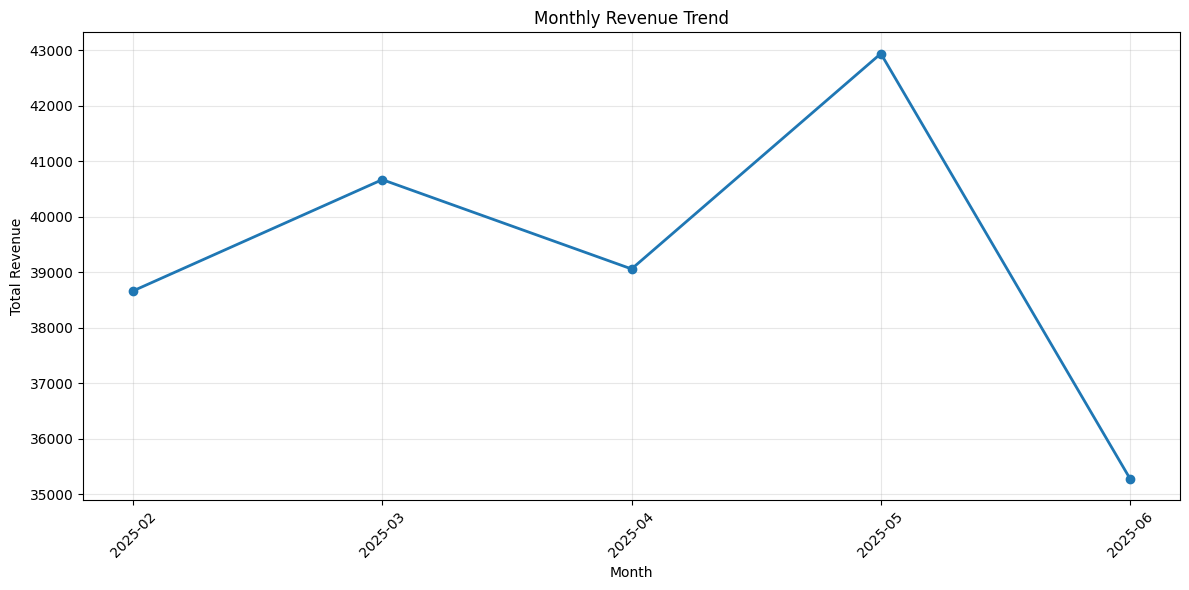

Monthly revenue plot created


In [24]:
# Monthly revenue trend
plt.figure(figsize=(12, 6))
monthly_pd['month_label'] = monthly_pd['order_year'].astype(str) + '-' + monthly_pd['order_month'].astype(str).str.zfill(2)
plt.plot(range(len(monthly_pd)), monthly_pd['total_revenue'], marker='o', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, alpha=0.3)
plt.xticks(range(len(monthly_pd)), monthly_pd['month_label'], rotation=45)
plt.tight_layout()
plt.show()

print("Monthly revenue plot created")

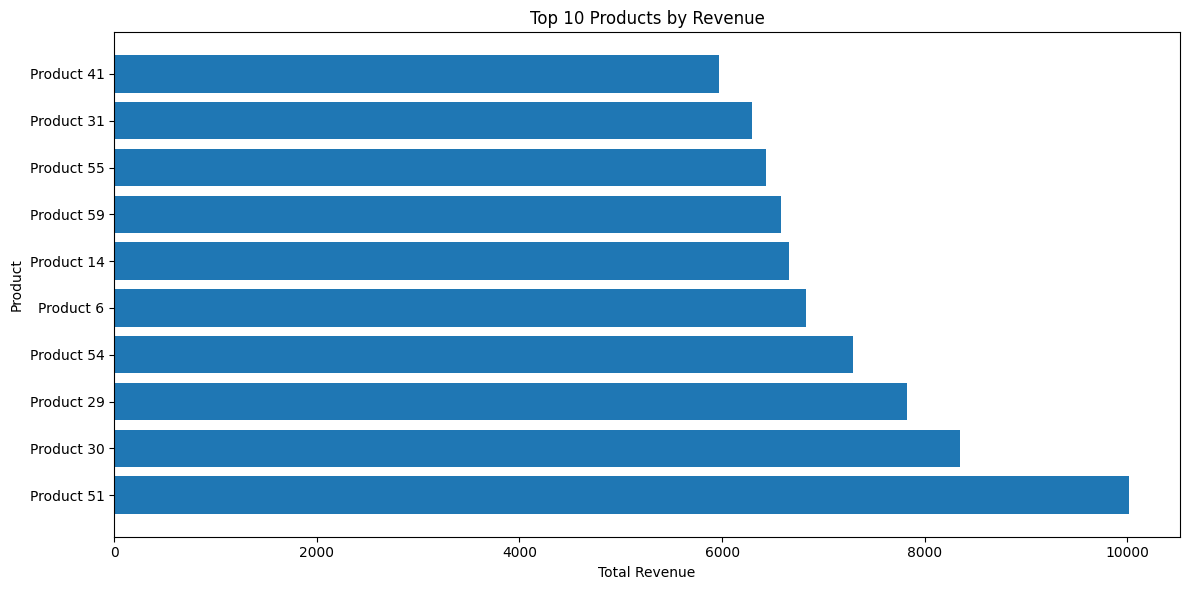

Product revenue plot created


In [25]:
# Top products by revenue
plt.figure(figsize=(12, 6))
plt.barh(product_pd['product_name'], product_pd['total_revenue'])
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

print("Product revenue plot created")

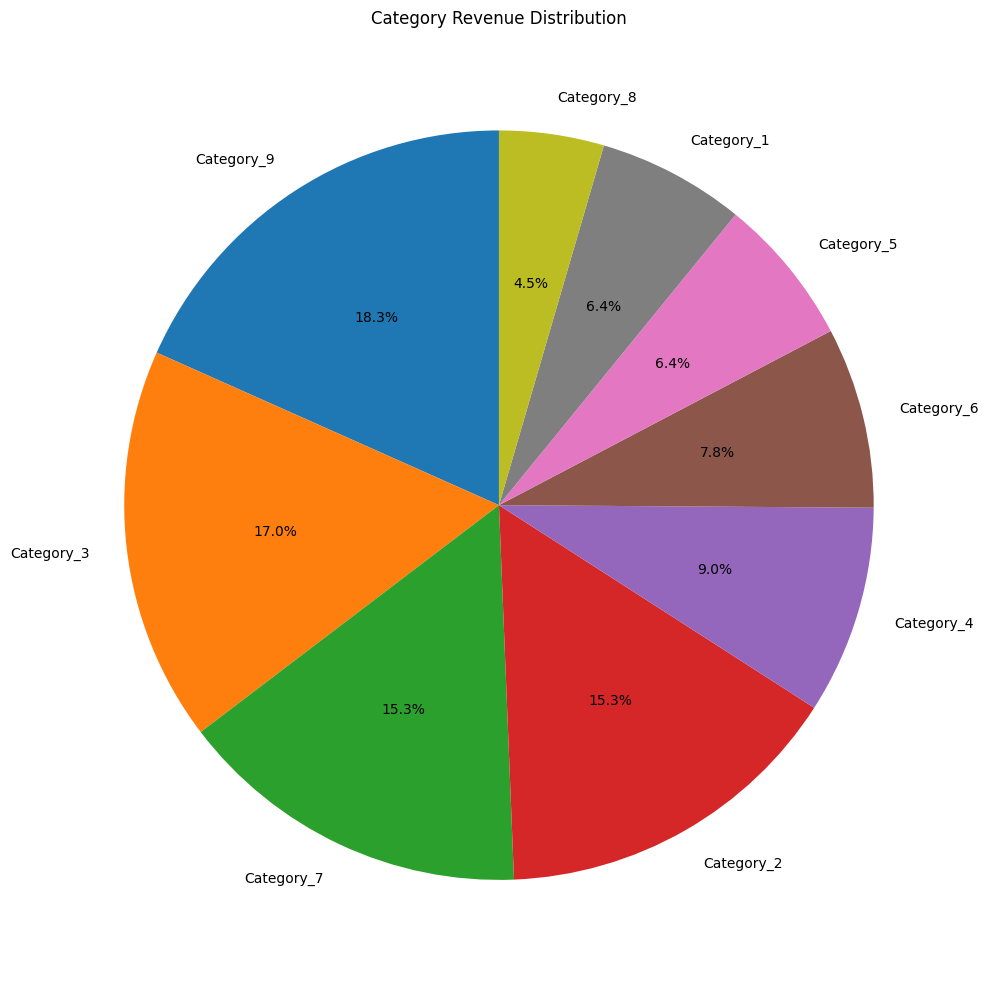

Category distribution plot created


In [26]:
# Category revenue distribution
plt.figure(figsize=(10, 10))
plt.pie(category_pd['total_revenue'], labels=category_pd['category_name'], autopct='%1.1f%%', startangle=90)
plt.title('Category Revenue Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

print("Category distribution plot created")

## Part 8: Data Export

In [27]:
# Export processed data
print("Exporting processed data...")

# Export customer statistics
customer_stats.write.mode("overwrite").parquet("output/customer_statistics")
print("Customer statistics exported")

# Export product statistics
product_stats.write.mode("overwrite").csv("output/product_statistics", header=True)
print("Product statistics exported")

# Export sales data
sales_df.write.mode("overwrite").parquet("output/sales_data")
print("Sales data exported")

Exporting processed data...


Customer statistics exported


Product statistics exported


Sales data exported


## Part 9: Summary and Conclusions

In [28]:
# Generate summary report
print("=" * 50)
print("ASSIGNMENT 2 SUMMARY REPORT")
print("=" * 50)

total_customers = customers_df.count()
total_orders = orders_df.count()
total_revenue = sales_df.agg(sum("total_price")).collect()[0][0]

print(f"\nData Overview:")
print(f"Total Customers: {total_customers}")
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ${total_revenue:.2f}")

print(f"\nKey Metrics:")
print(f"Average orders per customer: {total_orders / total_customers:.2f}")
print(f"Average revenue per order: ${total_revenue / total_orders:.2f}")

top_customer = customer_stats.first()
print(f"\nTop customer: {top_customer['name']} (${top_customer['total_spent']:.2f})")

top_product = product_stats.first()
print(f"Top product: {top_product['product_name']} (${top_product['total_revenue']:.2f})")

print("\nProcessing completed successfully!")
print("=" * 50)

ASSIGNMENT 2 SUMMARY REPORT



Data Overview:
Total Customers: 24
Total Orders: 220
Total Revenue: $196602.88

Key Metrics:
Average orders per customer: 9.17
Average revenue per order: $893.65



Top customer: Customer 11 ($12231.63)


Top product: Product 51 ($10018.57)

Processing completed successfully!


In [29]:
# Stop Spark session
spark.stop()
print("Spark session stopped")

Spark session stopped
